In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [ ]:
insurance= pd.DataFrame(pd.read_csv("/content/insurance.csv"))
insurance.head()


,age,gender,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
insurance.tail()

,age,gender,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


In [ ]:
insurance.shape

(1338, 7)

In [ ]:
insurance.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   gender    1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [ ]:
insurance.isnull().sum() #no missing values

age         0
gender      0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [ ]:
insurance.smoker.value_counts()

smoker
no     1064
yes     274
Name: count, dtype: int64

In [ ]:
dataMapping={"no":1,"yes":0} #converting the ordinal data to numerial data
insurance["smoker"]=insurance["smoker"].map(dataMapping)
insurance.head()


,age,gender,bmi,children,smoker,region,charges
0,19,female,27.900,0,0,southwest,16884.92400
1,18,male,33.770,1,1,southeast,1725.55230
2,28,male,33.000,3,1,southeast,4449.46200
3,33,male,22.705,0,1,northwest,21984.47061
4,32,male,28.880,0,1,northwest,3866.85520


In [ ]:
insurance.gender.value_counts()


gender
male      676
female    662
Name: count, dtype: int64

In [ ]:
insurance.region.value_counts()

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
insurance["region"]=le.fit_transform(insurance["region"])
insurance.head()

,age,gender,bmi,children,smoker,region,charges
0,19,female,27.900,0,0,3,16884.92400
1,18,male,33.770,1,1,2,1725.55230
2,28,male,33.000,3,1,2,4449.46200
3,33,male,22.705,0,1,1,21984.47061
4,32,male,28.880,0,1,1,3866.85520


In [ ]:
insurance.region.value_counts()

region
2    364
3    325
1    325
0    324
Name: count, dtype: int64

In [ ]:
dummies= pd.get_dummies(insurance["gender"]) #converting the categorical data to numerical data one hot Encoding
dummies


,female,male
0,True,False
1,False,True
2,False,True
3,False,True
4,False,True
...,...,...
1333,False,True
1334,True,False
1335,True,False
1336,True,False


In [ ]:
insurance= pd.concat([insurance, dummies], axis="columns")
insurance.head()

,age,gender,bmi,children,smoker,region,charges,female,male
0,19,female,27.900,0,0,3,16884.92400,True,False
1,18,male,33.770,1,1,2,1725.55230,False,True
2,28,male,33.000,3,1,2,4449.46200,False,True
3,33,male,22.705,0,1,1,21984.47061,False,True
4,32,male,28.880,0,1,1,3866.85520,False,True


In [ ]:
insurance.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   gender    1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   int64  
 5   region    1338 non-null   int64  
 6   charges   1338 non-null   float64
 7   female    1338 non-null   bool   
 8   male      1338 non-null   bool   
dtypes: bool(2), float64(2), int64(4), object(1)
memory usage: 75.9+ KB


In [ ]:
insurance["female"]=insurance["female"].astype(int)
insurance["male"]=insurance["male"].astype(int)
insurance.head()


,age,gender,bmi,children,smoker,region,charges,female,male
0,19,female,27.900,0,0,3,16884.92400,1,0
1,18,male,33.770,1,1,2,1725.55230,0,1
2,28,male,33.000,3,1,2,4449.46200,0,1
3,33,male,22.705,0,1,1,21984.47061,0,1
4,32,male,28.880,0,1,1,3866.85520,0,1


In [ ]:
del insurance["gender"]
insurance.head()

,age,bmi,children,smoker,region,charges,female,male
0,19,27.900,0,0,3,16884.92400,1,0
1,18,33.770,1,1,2,1725.55230,0,1
2,28,33.000,3,1,2,4449.46200,0,1
3,33,22.705,0,1,1,21984.47061,0,1
4,32,28.880,0,1,1,3866.85520,0,1


In [ ]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
insurance['charges'] = sc.fit_transform(insurance[['charges']])
insurance.head()


,age,bmi,children,smoker,region,charges,female,male
0,19,27.900,0,0,3,0.298584,1,0
1,18,33.770,1,1,2,-0.953689,0,1
2,28,33.000,3,1,2,-0.728675,0,1
3,33,22.705,0,1,1,0.719843,0,1
4,32,28.880,0,1,1,-0.776802,0,1


In [ ]:
X=insurance.drop(columns='charges').values
Y=insurance["charges"].values

print(X)


[[19.   27.9   0.   ...  3.    1.    0.  ]
 [18.   33.77  1.   ...  2.    0.    1.  ]
 [28.   33.    3.   ...  2.    0.    1.  ]
 ...
 [18.   36.85  0.   ...  2.    1.    0.  ]
 [21.   25.8   0.   ...  3.    1.    0.  ]
 [61.   29.07  0.   ...  1.    1.    0.  ]]


In [ ]:
print(Y)

[ 0.2985838  -0.95368917 -0.72867467 ... -0.96159623 -0.93036151
  1.31105347]


In [ ]:
from sklearn.model_selection import train_test_split
from pandas.core.common import random_state
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

x_train,x_test,y_train,y_test = train_test_split(X,Y,test_size=0.3,random_state=0)

In [ ]:
from sklearn.linear_model import LinearRegression
lr= LinearRegression()
lr.fit(x_train,y_train)

LinearRegression()

In [ ]:
y_pred_test =lr.predict(x_test)


In [ ]:
lr.predict([[19,27.900,0,0,3,1,0]])

array([0.95228845])

In [ ]:
from sklearn.metrics import r2_score
r2_score(y_test,y_pred_test)

0.7911113876316935

Text(0.5, 1.0, 'Actual vs Predicted (test data)')

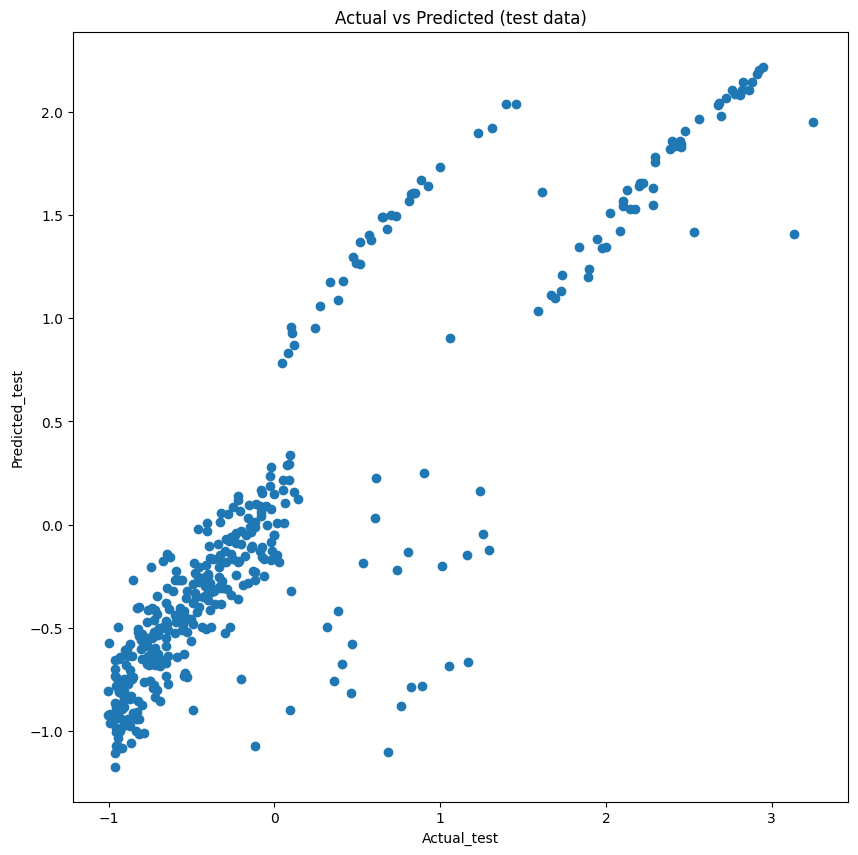

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,10))
plt.scatter(y_test,y_pred_test)
plt.xlabel('Actual_test')
plt.ylabel('Predicted_test')
plt.title('Actual vs Predicted (test data)')

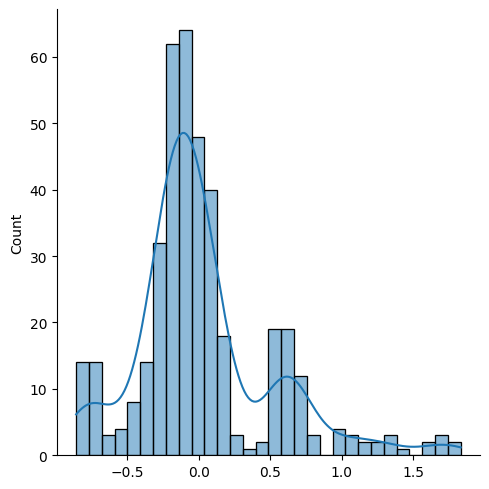

In [ ]:
import seaborn as sns
sns.displot((y_test-y_pred_test), kde=True)